In [1]:
import torch
import torch.nn as nn
from torchvision import datasets
from torch.utils.data import DataLoader
from torch.optim import Adam
from torchvision.transforms import ToTensor
from matplotlib import pyplot as plt

In [2]:
if torch.cuda.is_available():
    device=torch.device(type='cuda',index=0)
else:
    device=torch.device(type='cpu',index=0)

In [3]:
train_dataset=datasets.MNIST(root="/kaggle/temp/",
                            train=True,
                            download=True,
                            transform=ToTensor())

eval_dataset=datasets.MNIST(root="/kaggle/temp/",
                            train=False,
                            download=True,
                            transform=ToTensor())

batch_size=64

train_dataloader=DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
eval_dataloader=DataLoader(dataset=eval_dataset, batch_size=batch_size, shuffle=True)

100%|██████████| 9.91M/9.91M [00:00<00:00, 19.5MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 479kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.56MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 14.7MB/s]


In [ ]:
class Encoder1(nn.Module):
    def __init__(self):
        super().__init__()
        self.lkrelu=nn.LeakyReLU(0.1)
        self.l1=nn.Linear(in_features=784,out_features=512)
        self.l2=nn.Linear(in_features=512,out_features=256)

    def forward(self,x):
        net1=self.l1(x)
        out1=self.lkrelu(net1)
        net2=self.l2(out1)
        out2=self.lkrelu(net2)
        return out2

class Decoder1(nn.Module):
    def __init__(self):
        super().__init__()
        self.lkrelu=nn.LeakyReLU(0.1)
        self.sig=nn.Sigmoid()
        self.l1=nn.Linear(in_features=256,out_features=512)
        self.l2=nn.Linear(in_features=512,out_features=784)

    def forward(self,x):
        net1=self.l1(x)
        out1=self.lkrelu(net1)
        net2=self.l2(out1)
        out2=self.sig(net2)
        return out2

class Encoder2(nn.Module):
    def __init__(self):
        super().__init__()
        self.lkrelu=nn.LeakyReLU(0.1)
        self.l1=nn.Linear(in_features=256,out_features=100)

    def forward(self,x):
        net1=self.l1(x)
        out1=self.lkrelu(net1)
        return out1

class Decoder2(nn.Module):
    def __init__(self):
        super().__init__()
        self.lkrelu=nn.LeakyReLU(0.1)
        self.l1=nn.Linear(in_features=100,out_features=256)

    def forward(self,x):
        net1=self.l1(x)
        out1=self.lkrelu(net1)
        return out1


class Classifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.out=nn.Linear(in_features=100,out_features=10)

    def forward(self,x):
        out=self.out(x)
        return out

In [ ]:
lossmse_fn=nn.MSELoss()
lossentropy_fn=nn.CrossEntropyLoss()
lr=0.001

e1=Encoder1().to(device)
d1=Decoder1().to(device)
e2=Encoder2().to(device)
d2=Decoder2().to(device)
clf=Classifier().to(device)

opte1=Adam(params=e1.parameters(),lr=lr)
optd1=Adam(params=d1.parameters(),lr=lr)
opte2=Adam(params=e2.parameters(),lr=lr)
optd2=Adam(params=d2.parameters(),lr=lr)
optclf=Adam(params=clf.parameters(),lr=lr)

In [ ]:
#train AutoEncoder1
def train_e1d1():
    track_loss=0

    e1.train()
    d1.train()

    for i,(x,_) in enumerate(train_dataloader):
        x=torch.reshape(x,shape=(-1,784))
        x=x.to(device)

        latent=e1(x)
        pred=d1(latent)

        loss=lossmse_fn(pred,x)

        track_loss+=loss.item()

        loss.backward()

        opte1.step()
        optd1.step()

        opte1.zero_grad()
        optd1.zero_grad()

        running_loss=track_loss/(i+(x.shape[0]/batch_size))

    return round(running_loss,4)

#train AutoEncoder2
def train_e2d2():
    track_loss=0

    e2.train()
    d2.train()

    for i,(x,_) in enumerate(train_dataloader):
        x=torch.reshape(x,shape=(-1,784))
        x=x.to(device)

        latente1=e1(x)
        latente2=e2(latente1.detach())
        pred=d2(latente2)

        loss=lossmse_fn(pred,latente1.detach())

        track_loss+=loss.item()

        loss.backward()

        opte2.step()
        optd2.step()
        opte2.zero_grad()
        optd2.zero_grad()

        running_loss=track_loss/(i+(x.shape[0]/batch_size))

    return round(running_loss,4)

#train Classifier
def train_clf():
    track_loss=0
    num_correct=0

    clf.train()

    for i,(x,y) in enumerate(train_dataloader):
        x=torch.reshape(x,shape=(-1,784))
        x=x.to(device)
        y=y.to(device)

        latente1=e1(x)
        latente2=e2(latente1)
        pred=clf(latente2.detach())

        num_correct+=(torch.argmax(pred,dim=1)==y).type(torch.float).sum().item()

        loss=lossentropy_fn(pred,y)

        track_loss+=loss.item()

        loss.backward()

        optclf.step()
        optclf.zero_grad()

        running_loss=track_loss/(i+(x.shape[0]/batch_size))
        running_acc=(num_correct/((i*batch_size+x.shape[0])))*100

    return round(running_loss,4), round(running_acc,2)

#finetune whole
def train_whole():
    track_loss=0
    num_correct=0

    e1.train()
    e2.train()
    clf.train()

    for i,(x,y) in enumerate(train_dataloader):
        x=torch.reshape(x,shape=(-1,784))
        x=x.to(device)
        y=y.to(device)

        latente1=e1(x)
        latente2=e2(latente1)
        pred=clf(latente2)

        num_correct+=(torch.argmax(pred,dim=1)==y).type(torch.float).sum().item()

        loss=lossentropy_fn(pred,y)

        track_loss+=loss.item()

        loss.backward()

        opte1.step()
        opte2.step()
        optclf.step()

        opte1.zero_grad()
        opte2.zero_grad()
        optclf.zero_grad()

        running_loss=track_loss/(i+(x.shape[0]/batch_size))
        running_acc=(num_correct/((i*batch_size+x.shape[0])))*100

    return round(running_loss,4),round(running_acc,2)


In [ ]:
def eval_e1d1():
    e1.eval()
    d1.eval()

    with torch.no_grad():
        for i,(x,_) in enumerate(eval_dataloader):
            x=torch.reshape(x,shape=(-1,784))
            x=x.to(device)

            latent=e1(x)
            pred=d1(latent)

            loss=lossmse_fn(pred,x)

    return round(loss.item(),4),x,pred

#Eval AutoEncoder2
def eval_e2d2():
    e2.eval()
    d2.eval()

    with torch.no_grad():
        for i,(x,_) in enumerate(eval_dataloader):
            x=torch.reshape(x,shape=(-1,784))
            x=x.to(device)

            latente1=e1(x)
            latente2=e2(latente1)
            pred=d2(latente2)

            loss=lossmse_fn(pred,latente1)

    return round(loss.item(),4)


#Eval Classifier
def eval_clf():
    num_correct=0

    clf.eval()

    with torch.no_grad():
        for i,(x,y) in enumerate(eval_dataloader):
            x=torch.reshape(x,shape=(-1,784))
            x=x.to(device)
            y=y.to(device)

            latente1=e1(x)
            latente2=e2(latente1)
            pred=clf(latente2)

            num_correct+=(torch.argmax(pred,dim=1)==y).type(torch.float).sum().item()
            running_acc=(num_correct/((i*batch_size+x.shape[0])))*100

            loss=lossentropy_fn(pred,y)

    return round(loss.item(),4), round(running_acc,2)

#eval whole
def eval_whole():
    num_correct=0

    e1.eval()
    e2.eval()
    clf.eval()
    with torch.no_grad():
        for i,(x,y) in enumerate(eval_dataloader):
            x=torch.reshape(x,shape=(-1,784))
            x=x.to(device)
            y=y.to(device)

            latente1=e1(x)
            latente2=e2(latente1)
            pred=clf(latente2)

            num_correct+=(torch.argmax(pred,dim=1)==y).type(torch.float).sum().item()
            running_acc=(num_correct/((i*batch_size+x.shape[0])))*100

            loss=lossentropy_fn(pred,y)

    return round(loss.item(),4), round(running_acc,2)

-----------------------Auto Encoder 1------------------------
Epoch=1, Train Loss=0.0225, Eval Loss=0.0083
Epoch=2, Train Loss=0.0067, Eval Loss=0.0064
Epoch=3, Train Loss=0.0048, Eval Loss=0.0046
Epoch=4, Train Loss=0.0039, Eval Loss=0.0036
Epoch=5, Train Loss=0.0034, Eval Loss=0.0035
Epoch=6, Train Loss=0.003, Eval Loss=0.0031
Epoch=7, Train Loss=0.0028, Eval Loss=0.0027
Epoch=8, Train Loss=0.0025, Eval Loss=0.0029
Epoch=9, Train Loss=0.0024, Eval Loss=0.0024
Epoch=10, Train Loss=0.0022, Eval Loss=0.0027


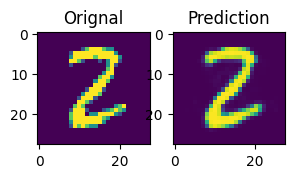

-----------------------Auto Encoder 2------------------------
Epoch=1, Train Loss=0.2788, Eval Loss=0.0548
Epoch=2, Train Loss=0.042, Eval Loss=0.0253
Epoch=3, Train Loss=0.0231, Eval Loss=0.0189
Epoch=4, Train Loss=0.0181, Eval Loss=0.0149
Epoch=5, Train Loss=0.0161, Eval Loss=0.0139
Epoch=6, Train Loss=0.0153, Eval Loss=0.0127
Epoch=7, Train Loss=0.0151, Eval Loss=0.0153
Epoch=8, Train Loss=0.0149, Eval Loss=0.0148
Epoch=9, Train Loss=0.0148, Eval Loss=0.0144
Epoch=10, Train Loss=0.0148, Eval Loss=0.0152
-----------------------Classifier Only------------------------
Epoch=1, Train Loss & Accuracy=(1.0078, 72.4), Eval Loss & Accuracy=(0.4817, 87.87)
Epoch=2, Train Loss & Accuracy=(0.4596, 87.98), Eval Loss & Accuracy=(0.7514, 89.93)
Epoch=3, Train Loss & Accuracy=(0.3881, 89.38), Eval Loss & Accuracy=(0.6175, 90.17)
Epoch=4, Train Loss & Accuracy=(0.3579, 90.11), Eval Loss & Accuracy=(0.2835, 91.05)
Epoch=5, Train Loss & Accuracy=(0.341, 90.38), Eval Loss & Accuracy=(0.5287, 91.29)
Ep

In [ ]:
n_epochs=10

print("-----------------------Auto Encoder 1------------------------")
for i in range(n_epochs):
    train_loss=train_e1d1()
    eval_loss,x,pred=eval_e1d1()
    print("Epoch=", i+1,", Train Loss=",train_loss,", Eval Loss=",eval_loss,sep="")

plt.figure(figsize=(3.2,2.4))

r=torch.randint(low=0,high=pred.shape[0],size=(1,)).item()

plt.subplot(1,2,1)
plt.title("Orignal")
plt.imshow(torch.reshape(x[r],shape=(28,28)).cpu())

plt.subplot(1,2,2)
plt.title("Prediction")
plt.imshow(torch.reshape(pred[r],shape=(28,28)).cpu())
plt.show()

print("-----------------------Auto Encoder 2------------------------")
for i in range(n_epochs):
    print("Epoch=", i+1,", Train Loss=",train_e2d2(),", Eval Loss=",eval_e2d2(),sep="")


print("-----------------------Classifier Only------------------------")
for i in range(n_epochs):
    print("Epoch=", i+1,", Train Loss & Accuracy=",train_clf(),", Eval Loss & Accuracy=",eval_clf(),sep="")


print("--------------------Fine-Tuning Whole Metwork------------------")
for i in range(n_epochs):
    print("Epoch=", i+1,", Train Loss & Accuracy=",train_whole(),", Eval Loss & Accuracy=",eval_whole(),sep="")

Now i want to train model by making simple neural network train it entirely
784 512 256 100 10
simple classifier and train again

In [11]:
import torch
import torch.nn as nn
from torchvision import datasets
from torch.utils.data import DataLoader
from torch.optim import Adam
from torchvision.transforms import ToTensor
from matplotlib import pyplot as plt

# ── Device ──────────────────────────────────────────────────────────────────
if torch.cuda.is_available():
    device = torch.device(type='cuda', index=0)
else:
    device = torch.device(type='cpu', index=0)

# ── Data ─────────────────────────────────────────────────────────────────────
train_dataset = datasets.MNIST(root="/kaggle/temp/", train=True,  download=True, transform=ToTensor())
eval_dataset  = datasets.MNIST(root="/kaggle/temp/", train=False, download=True, transform=ToTensor())

batch_size = 64

train_dataloader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
eval_dataloader  = DataLoader(dataset=eval_dataset,  batch_size=batch_size, shuffle=True)

# ── Autoencoder Models ───────────────────────────────────────────────────────
class Encoder1(nn.Module):
    def __init__(self):
        super().__init__()
        self.lkrelu = nn.LeakyReLU(0.1)
        self.l1 = nn.Linear(784, 512)
        self.l2 = nn.Linear(512, 256)

    def forward(self, x):
        return self.lkrelu(self.l2(self.lkrelu(self.l1(x))))


class Decoder1(nn.Module):
    def __init__(self):
        super().__init__()
        self.lkrelu = nn.LeakyReLU(0.1)
        self.sig    = nn.Sigmoid()
        self.l1 = nn.Linear(256, 512)
        self.l2 = nn.Linear(512, 784)

    def forward(self, x):
        return self.sig(self.l2(self.lkrelu(self.l1(x))))


class Encoder2(nn.Module):
    def __init__(self):
        super().__init__()
        self.lkrelu = nn.LeakyReLU(0.1)
        self.l1 = nn.Linear(256, 100)

    def forward(self, x):
        return self.lkrelu(self.l1(x))


class Decoder2(nn.Module):
    def __init__(self):
        super().__init__()
        self.lkrelu = nn.LeakyReLU(0.1)
        self.l1 = nn.Linear(100, 256)

    def forward(self, x):
        return self.lkrelu(self.l1(x))


class Classifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.out = nn.Linear(100, 10)

    def forward(self, x):
        return self.out(x)




In [12]:
# ── Simple End-to-End Classifier (784→512→256→100→10) ────────────────────────
class SimpleClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.lkrelu = nn.LeakyReLU(0.1)
        self.l1 = nn.Linear(784, 512)
        self.l2 = nn.Linear(512, 256)
        self.l3 = nn.Linear(256, 100)
        self.l4 = nn.Linear(100, 10)

    def forward(self, x):
        x = self.lkrelu(self.l1(x))
        x = self.lkrelu(self.l2(x))
        x = self.lkrelu(self.l3(x))
        return self.l4(x)  # raw logits


# ── Instantiate Models ───────────────────────────────────────────────────────
e1         = Encoder1().to(device)
d1         = Decoder1().to(device)
e2         = Encoder2().to(device)
d2         = Decoder2().to(device)
clf        = Classifier().to(device)
simple_clf = SimpleClassifier().to(device)

# ── Loss & Optimizers ────────────────────────────────────────────────────────
lr               = 0.001
lossmse_fn       = nn.MSELoss()
lossentropy_fn   = nn.CrossEntropyLoss()

opte1      = Adam(e1.parameters(),         lr=lr)
optd1      = Adam(d1.parameters(),         lr=lr)
opte2      = Adam(e2.parameters(),         lr=lr)
optd2      = Adam(d2.parameters(),         lr=lr)
optclf     = Adam(clf.parameters(),        lr=lr)
opt_simple = Adam(simple_clf.parameters(), lr=lr)



In [13]:
# ── Train / Eval Functions (Autoencoder) ─────────────────────────────────────
def train_e1d1():
    e1.train(); d1.train()
    track_loss = 0
    for i, (x, _) in enumerate(train_dataloader):
        x = torch.reshape(x, (-1, 784)).to(device)
        loss = lossmse_fn(d1(e1(x)), x)
        loss.backward()
        opte1.step(); optd1.step()
        opte1.zero_grad(); optd1.zero_grad()
        track_loss += loss.item()
        running_loss = track_loss / (i + (x.shape[0] / batch_size))
    return round(running_loss, 4)

def eval_e1d1():
    e1.eval(); d1.eval()
    with torch.no_grad():
        for i, (x, _) in enumerate(eval_dataloader):
            x = torch.reshape(x, (-1, 784)).to(device)
            pred = d1(e1(x))
            loss = lossmse_fn(pred, x)
    return round(loss.item(), 4), x, pred

def train_e2d2():
    e2.train(); d2.train()
    track_loss = 0
    for i, (x, _) in enumerate(train_dataloader):
        x = torch.reshape(x, (-1, 784)).to(device)
        latente1 = e1(x)
        latente2 = e2(latente1.detach())
        loss = lossmse_fn(d2(latente2), latente1.detach())
        loss.backward()
        opte2.step(); optd2.step()
        opte2.zero_grad(); optd2.zero_grad()
        track_loss += loss.item()
        running_loss = track_loss / (i + (x.shape[0] / batch_size))
    return round(running_loss, 4)

def eval_e2d2():
    e2.eval(); d2.eval()
    with torch.no_grad():
        for i, (x, _) in enumerate(eval_dataloader):
            x = torch.reshape(x, (-1, 784)).to(device)
            latente1 = e1(x)
            loss = lossmse_fn(d2(e2(latente1)), latente1)
    return round(loss.item(), 4)

def train_clf():
    clf.train()
    track_loss = 0; num_correct = 0
    for i, (x, y) in enumerate(train_dataloader):
        x = torch.reshape(x, (-1, 784)).to(device); y = y.to(device)
        latente2 = e2(e1(x))
        pred = clf(latente2.detach())
        loss = lossentropy_fn(pred, y)
        loss.backward()
        optclf.step(); optclf.zero_grad()
        track_loss  += loss.item()
        num_correct += (torch.argmax(pred, dim=1) == y).float().sum().item()
        running_loss = track_loss / (i + (x.shape[0] / batch_size))
        running_acc  = (num_correct / ((i * batch_size + x.shape[0]))) * 100
    return round(running_loss, 4), round(running_acc, 2)

def eval_clf():
    clf.eval()
    num_correct = 0
    with torch.no_grad():
        for i, (x, y) in enumerate(eval_dataloader):
            x = torch.reshape(x, (-1, 784)).to(device); y = y.to(device)
            pred = clf(e2(e1(x)))
            loss = lossentropy_fn(pred, y)
            num_correct += (torch.argmax(pred, dim=1) == y).float().sum().item()
            running_acc  = (num_correct / ((i * batch_size + x.shape[0]))) * 100
    return round(loss.item(), 4), round(running_acc, 2)

def train_whole():
    e1.train(); e2.train(); clf.train()
    track_loss = 0; num_correct = 0
    for i, (x, y) in enumerate(train_dataloader):
        x = torch.reshape(x, (-1, 784)).to(device); y = y.to(device)
        pred = clf(e2(e1(x)))
        loss = lossentropy_fn(pred, y)
        loss.backward()
        opte1.step(); opte2.step(); optclf.step()
        opte1.zero_grad(); opte2.zero_grad(); optclf.zero_grad()
        track_loss  += loss.item()
        num_correct += (torch.argmax(pred, dim=1) == y).float().sum().item()
        running_loss = track_loss / (i + (x.shape[0] / batch_size))
        running_acc  = (num_correct / ((i * batch_size + x.shape[0]))) * 100
    return round(running_loss, 4), round(running_acc, 2)

def eval_whole():
    e1.eval(); e2.eval(); clf.eval()
    num_correct = 0
    with torch.no_grad():
        for i, (x, y) in enumerate(eval_dataloader):
            x = torch.reshape(x, (-1, 784)).to(device); y = y.to(device)
            pred = clf(e2(e1(x)))
            loss = lossentropy_fn(pred, y)
            num_correct += (torch.argmax(pred, dim=1) == y).float().sum().item()
            running_acc  = (num_correct / ((i * batch_size + x.shape[0]))) * 100
    return round(loss.item(), 4), round(running_acc, 2)

# ── Train / Eval Functions (Simple Classifier) ───────────────────────────────
def train_simple_clf():
    simple_clf.train()
    track_loss = 0; num_correct = 0
    for i, (x, y) in enumerate(train_dataloader):
        x = torch.reshape(x, (-1, 784)).to(device); y = y.to(device)
        pred = simple_clf(x)
        loss = lossentropy_fn(pred, y)
        loss.backward()
        opt_simple.step(); opt_simple.zero_grad()
        track_loss  += loss.item()
        num_correct += (torch.argmax(pred, dim=1) == y).float().sum().item()
        running_loss = track_loss / (i + (x.shape[0] / batch_size))
        running_acc  = (num_correct / ((i * batch_size + x.shape[0]))) * 100
    return round(running_loss, 4), round(running_acc, 2)

def eval_simple_clf():
    simple_clf.eval()
    num_correct = 0
    with torch.no_grad():
        for i, (x, y) in enumerate(eval_dataloader):
            x = torch.reshape(x, (-1, 784)).to(device); y = y.to(device)
            pred = simple_clf(x)
            loss = lossentropy_fn(pred, y)
            num_correct += (torch.argmax(pred, dim=1) == y).float().sum().item()
            running_acc  = (num_correct / ((i * batch_size + x.shape[0]))) * 100
    return round(loss.item(), 4), round(running_acc, 2)



-----------------------Auto Encoder 1------------------------
Epoch=1, Train Loss=0.0223, Eval Loss=0.007
Epoch=2, Train Loss=0.0067, Eval Loss=0.0049
Epoch=3, Train Loss=0.0048, Eval Loss=0.0039
Epoch=4, Train Loss=0.0039, Eval Loss=0.0032
Epoch=5, Train Loss=0.0034, Eval Loss=0.0035
Epoch=6, Train Loss=0.003, Eval Loss=0.0023
Epoch=7, Train Loss=0.0027, Eval Loss=0.0023
Epoch=8, Train Loss=0.0026, Eval Loss=0.0028
Epoch=9, Train Loss=0.0024, Eval Loss=0.0023
Epoch=10, Train Loss=0.0023, Eval Loss=0.0023


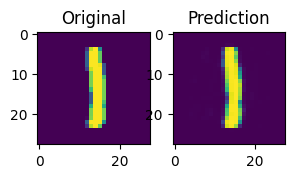

-----------------------Auto Encoder 2------------------------
Epoch=1, Train Loss=0.2947, Eval Loss=0.0729
Epoch=2, Train Loss=0.0437, Eval Loss=0.0266
Epoch=3, Train Loss=0.0239, Eval Loss=0.0222
Epoch=4, Train Loss=0.0184, Eval Loss=0.0136
Epoch=5, Train Loss=0.016, Eval Loss=0.0142
Epoch=6, Train Loss=0.0153, Eval Loss=0.0143
Epoch=7, Train Loss=0.015, Eval Loss=0.0115
Epoch=8, Train Loss=0.0149, Eval Loss=0.017
Epoch=9, Train Loss=0.0147, Eval Loss=0.0141
Epoch=10, Train Loss=0.0147, Eval Loss=0.0142
-----------------------Classifier Only------------------------
Epoch=1, Train=(0.9614, 73.46), Eval=(0.6041, 87.53)
Epoch=2, Train=(0.4519, 88.01), Eval=(0.3881, 89.99)
Epoch=3, Train=(0.3844, 89.43), Eval=(0.0625, 90.32)
Epoch=4, Train=(0.357, 89.93), Eval=(0.1417, 90.48)
Epoch=5, Train=(0.3423, 90.23), Eval=(0.0963, 90.97)
Epoch=6, Train=(0.3335, 90.59), Eval=(0.2791, 90.83)
Epoch=7, Train=(0.3278, 90.7), Eval=(0.4344, 91.04)
Epoch=8, Train=(0.324, 90.81), Eval=(0.554, 91.25)
Epoch=9

In [14]:
# ── Training ─────────────────────────────────────────────────────────────────
n_epochs = 10

print("-----------------------Auto Encoder 1------------------------")
for i in range(n_epochs):
    train_loss = train_e1d1()
    eval_loss, x, pred = eval_e1d1()
    print(f"Epoch={i+1}, Train Loss={train_loss}, Eval Loss={eval_loss}")

plt.figure(figsize=(3.2, 2.4))
r = torch.randint(low=0, high=pred.shape[0], size=(1,)).item()
plt.subplot(1, 2, 1); plt.title("Original");   plt.imshow(torch.reshape(x[r],    (28,28)).cpu())
plt.subplot(1, 2, 2); plt.title("Prediction"); plt.imshow(torch.reshape(pred[r], (28,28)).cpu())
plt.show()

print("-----------------------Auto Encoder 2------------------------")
for i in range(n_epochs):
    print(f"Epoch={i+1}, Train Loss={train_e2d2()}, Eval Loss={eval_e2d2()}")

print("-----------------------Classifier Only------------------------")
for i in range(n_epochs):
    print(f"Epoch={i+1}, Train={train_clf()}, Eval={eval_clf()}")

print("--------------------Fine-Tuning Whole Network------------------")
for i in range(n_epochs):
    print(f"Epoch={i+1}, Train={train_whole()}, Eval={eval_whole()}")

print("-----------Simple End-to-End Classifier (784-512-256-100-10)-----------")
for i in range(n_epochs):
    tr_loss, tr_acc = train_simple_clf()
    ev_loss, ev_acc = eval_simple_clf()
    print(f"Epoch={i+1}, Train Loss={tr_loss}, Train Acc={tr_acc}%, Eval Loss={ev_loss}, Eval Acc={ev_acc}%")